In [16]:
# while our heights scraper is dutifully scraping the heights, we will operate height agnostic
# taller and shorter guys will be penalized more in our first iteration

from pathlib import Path
import polars as pl
import pandas as pd
import numpy as np

DATA_DIR = Path("../../data_pipeline/wbaserunners/D1/2026")
lf = (
    pl.scan_parquet(str(DATA_DIR / "**/*.parquet"))
    .select([
        "GameUID", "Batter", "BatterSide", "AutoPitchType",
        "Balls", "Strikes",  
        "Outs", "PitchCall",
        "PlateLocHeight", "PlateLocSide"
    ])
    .drop_nulls()
    .filter(
        pl.col("PitchCall").is_in(["BallinDirt", "BallCalled", "StrikeCalled"]),
        pl.col("BatterSide").is_in(["Right", "Left"]) # switch batters are real and noise
    )
    .filter(
        pl.col("PlateLocSide").abs() <= 3, 
        pl.col("PlateLocHeight") >= 0, 
        pl.col("PlateLocHeight") <= 5.5
    )
    .with_columns(
    (pl.col("BatterSide") == "Left").cast(pl.Int8).alias("BatterSide")   # 0 = R, 1 = L
    )
)
df = lf.collect()
df = df.to_pandas()
df.shape

(1067085, 10)

In [17]:
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.calibration import calibration_curve

features = ["BatterSide", "Balls", "Strikes", "PlateLocHeight", "PlateLocSide"]
target = "PitchCall"
X = df[features]
y = (df[target] == "StrikeCalled").astype(int)

## Splitting training sets by game rather than random so the model doesn't memorize umpires
groups = df["GameUID"]

# outer split: holding out test Games 
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
trainval_idx, test_idx = next(gss.split(X, y, groups))

X_trv, X_te = X.iloc[trainval_idx], X.iloc[test_idx]
y_trv, y_te = y.iloc[trainval_idx], y.iloc[test_idx]
g_trv = groups.iloc[trainval_idx]

# inner split
gss2 = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=1)
tr_idx, val_idx = next(gss2.split(X_trv, y_trv, g_trv))
X_tr, y_tr = X_trv.iloc[tr_idx], y_trv.iloc[tr_idx]
X_val, y_val = X_trv.iloc[val_idx], y_trv.iloc[val_idx]

# save the split so v1 vs v2 are comparable
pd.DataFrame(
    {"GameUID": groups.iloc[test_idx].unique()}).to_parquet("umpire_test_games.parquet"
)

ump_model = lgb.LGBMClassifier(
    objective="binary", learning_rate=0.05, num_leaves=31, max_depth=6,
    min_child_samples=500, n_estimators=2000, n_jobs=-1, random_state=42,
)

ump_model.fit(X_val, y_val, eval_set=[(X_te, y_te)], eval_metric="binary_logloss",
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

p = ump_model.predict_proba(X_te)[:, 1]
print("log loss:", log_loss(y_te, p), " brier:", brier_score_loss(y_te, p))
frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=15)

[LightGBM] [Info] Number of positive: 55345, number of negative: 115234
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001232 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 519
[LightGBM] [Info] Number of data points in the train set: 170579, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.324454 -> initscore=-0.733379
[LightGBM] [Info] Start training from score -0.733379
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[175]	valid_0's binary_logloss: 0.213198
log loss: 0.21319799846253407  brier: 0.0642280583854856


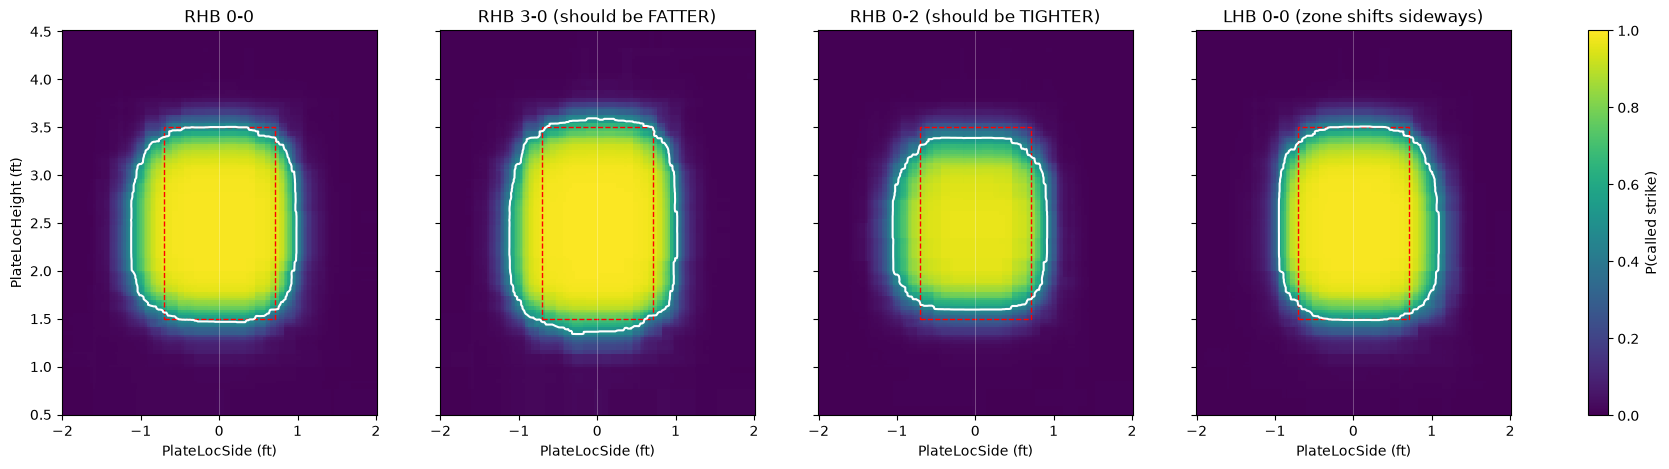

In [18]:
# Sanity heat map
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

PLATE_HALF = 0.708  # 8.5 in in feet — plate half-width for reference

def strike_surface(model, batterside, balls, strikes, n=200,
                   x_range=(-2.0, 2.0), z_range=(0.5, 4.5)):
    xs = np.linspace(*x_range, n)
    zs = np.linspace(*z_range, n)
    XX, ZZ = np.meshgrid(xs, zs)
    grid = pd.DataFrame({
        "BatterSide": batterside, "Balls": balls, "Strikes": strikes,
        "PlateLocHeight": ZZ.ravel(), "PlateLocSide": XX.ravel(),
    })[features]                                   # exact training column order
    p = model.predict_proba(grid)[:, 1].reshape(XX.shape)
    return xs, zs, p

# (title, batterside, balls, strikes)
panels = [
    ("RHB 0-0", 0, 0, 0),
    ("RHB 3-0 (should be FATTER)", 0, 3, 0),
    ("RHB 0-2 (should be TIGHTER)", 0, 0, 2),
    ("LHB 0-0 (zone shifts sideways)", 1, 0, 0),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, (title, bs, b, s) in zip(axes, panels):
    xs, zs, surf = strike_surface(ump_model, bs, b, s)
    im = ax.pcolormesh(xs, zs, surf, cmap="viridis", vmin=0, vmax=1, shading="auto")
    ax.contour(xs, zs, surf, levels=[0.5], colors="white", linewidths=1.5)  # zone edge
    ax.add_patch(Rectangle((-PLATE_HALF, 1.5), 2*PLATE_HALF, 2.0,
                           fill=False, edgecolor="red", ls="--", lw=1))  # rough plate ref
    ax.set_title(title); ax.set_xlabel("PlateLocSide (ft)")
    ax.axvline(0, color="w", lw=0.5, alpha=0.4)
axes[0].set_ylabel("PlateLocHeight (ft)")
fig.colorbar(im, ax=axes, label="P(called strike)", fraction=0.015)
plt.show()

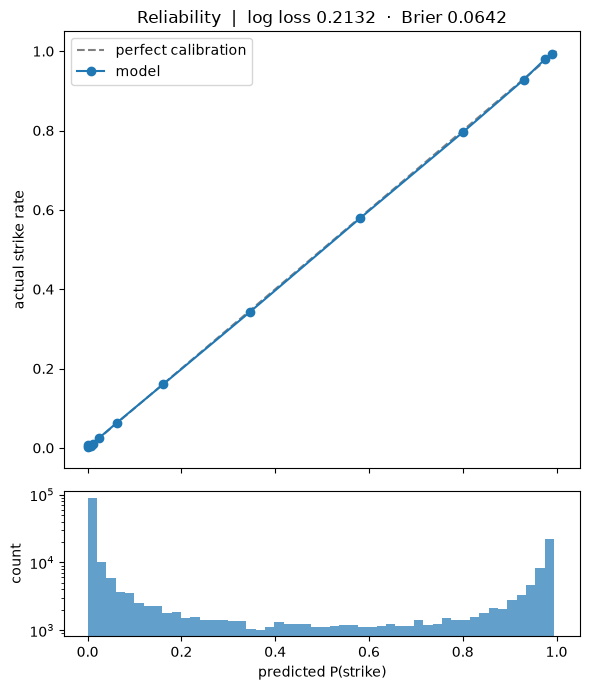

In [19]:
from sklearn.calibration import calibration_curve

p = ump_model.predict_proba(X_te)[:, 1] 
frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=15, strategy="quantile")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7),
                               gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
ax1.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
ax1.plot(mean_pred, frac_pos, "o-", color="C0", label="model")
ax1.set_ylabel("actual strike rate"); ax1.legend(loc="upper left")
ax1.set_title(f"Reliability  |  log loss {log_loss(y_te, p):.4f}  ·  Brier {brier_score_loss(y_te, p):.4f}")

ax2.hist(p, bins=50, color="C0", alpha=0.7)
ax2.set_xlabel("predicted P(strike)"); ax2.set_ylabel("count"); ax2.set_yscale("log")
plt.tight_layout(); plt.show()

In [20]:
# Swing model P(Swing) given location, count, etc.
# bringing in new dataset
swing = ["StrikeSwinging", "InPlay", "FoulBall", "FoulBallFieldable", "FoulBallNotFieldable"] # previous trackman csvs will have foulball as the tag

lf2 = (
    pl.scan_parquet(str(DATA_DIR / "**/*.parquet"))
    .select([
        "GameUID", "Batter", "BatterSide", "AutoPitchType",
        "Balls", "Strikes",  
        "Outs", "PitchCall",
        "PlateLocHeight", "PlateLocSide"
    ])
    .drop_nulls()
    .filter(
        pl.col("PitchCall").is_in(swing + ["BallCalled", "StrikeCalled", "BallinDirt"]),
        pl.col("BatterSide").is_in(["Right", "Left"]) # switch batters are real and noise
    )
    .filter(
        pl.col("PlateLocSide").abs() <= 3, 
        pl.col("PlateLocHeight") >= 0, 
        pl.col("PlateLocHeight") <= 5.5
    )
    # for pitch families
    .filter(
        ~pl.col("AutoPitchType").is_in(["Other"])
    )
    .with_columns(
        (pl.col("BatterSide") == "Left").cast(pl.Int8).alias("BatterSide")   # 0 = R, 1 = L
    )
)
df2 = lf2.collect()
df2 = df2.to_pandas()
df2.shape

# Pitch family 
FAMILY = {
    "Four-Seam": "Fastball",
    "Sinker": "Fastball",
    "Changeup": "Offspeed",
    "Slider": "Breaking",
    "Curveball": "Breaking",
    "Cutter": "Breaking", # in my opinion, cutters are more like breaking balls in college ball
    "Splitter": "Offspeed"
}
df2["PitchFamily"] = df2["AutoPitchType"].map(FAMILY).fillna("Unknown").astype("category")
print(df2["PitchFamily"].unique())

['Fastball', 'Offspeed', 'Breaking']
Categories (3, str): ['Breaking', 'Fastball', 'Offspeed']


In [21]:
features = ["BatterSide", "Balls", "Strikes", "PlateLocHeight", "PlateLocSide", "PitchFamily"]
target = "PitchCall"
X = df2[features]
y = (df2[target].isin(swing)).astype(int)

## Splitting training sets by game rather than random so the model doesn't memorize umpires
groups = df2["GameUID"]

# outer split: holding out test Games 
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
trainval_idx, test_idx = next(gss.split(X, y, groups))

X_trv, X_te = X.iloc[trainval_idx], X.iloc[test_idx]
y_trv, y_te = y.iloc[trainval_idx], y.iloc[test_idx]
g_trv = groups.iloc[trainval_idx]

# inner split
gss2 = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=1)
tr_idx, val_idx = next(gss2.split(X_trv, y_trv, g_trv))
X_tr, y_tr = X_trv.iloc[tr_idx], y_trv.iloc[tr_idx]
X_val, y_val = X_trv.iloc[val_idx], y_trv.iloc[val_idx]

# save the split so v1 vs v2 are comparable
pd.DataFrame(
    {"GameUID": groups.iloc[test_idx].unique()}).to_parquet("swing_test_games.parquet"
)

swing_model = lgb.LGBMClassifier(
    objective="binary", learning_rate=0.05, num_leaves=31, max_depth=6,
    min_child_samples=500, n_estimators=2000, n_jobs=-1, random_state=42,
)

swing_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="binary_logloss",
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

p = swing_model.predict_proba(X_te)[:, 1]
print("log loss:", log_loss(y_te, p), " brier:", brier_score_loss(y_te, p))
frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=15)

[LightGBM] [Info] Number of positive: 542570, number of negative: 684244
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007887 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 523
[LightGBM] [Info] Number of data points in the train set: 1226814, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.442259 -> initscore=-0.231997
[LightGBM] [Info] Start training from score -0.231997
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[594]	valid_0's binary_logloss: 0.474657
log loss: 0.47888393906581  brier: 0.15880861849686104


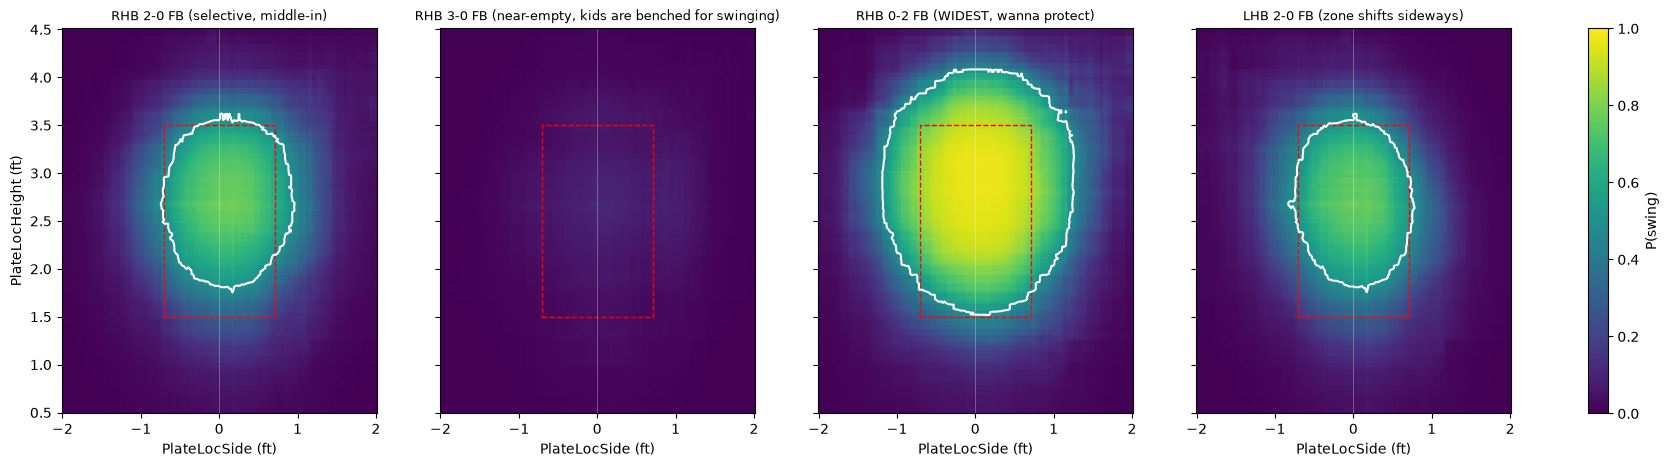

In [22]:
# Sanity heat map for swings
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

PLATE_HALF = 0.708
FAM_CATS = df2["PitchFamily"].cat.categories        # match training categories exactly

def swing_surface(model, batterside, balls, strikes, family, n=200,
                  x_range=(-2.0, 2.0), z_range=(0.5, 4.5)):
    xs = np.linspace(*x_range, n)
    zs = np.linspace(*z_range, n)
    XX, ZZ = np.meshgrid(xs, zs)
    grid = pd.DataFrame({
        "BatterSide": batterside, "Balls": balls, "Strikes": strikes,
        "PlateLocHeight": ZZ.ravel(), "PlateLocSide": XX.ravel(),
    })
    grid["PitchFamily"] = pd.Categorical([family] * len(grid), categories=FAM_CATS)
    p = model.predict_proba(grid[features])[:, 1].reshape(XX.shape)
    return xs, zs, p

panels = [
    ("RHB 2-0 FB (selective, middle-in)",      0, 2, 0, "Fastball"),
    ("RHB 3-0 FB (near-empty, kids are benched for swinging)",  0, 3, 0, "Fastball"),
    ("RHB 0-2 FB (WIDEST, wanna protect)", 0, 0, 2, "Fastball"),
    ("LHB 2-0 FB (zone shifts sideways)",       1, 2, 0, "Fastball"),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, (title, bs, b, s, fam) in zip(axes, panels):
    xs, zs, surf = swing_surface(swing_model, bs, b, s, fam)
    im = ax.pcolormesh(xs, zs, surf, cmap="viridis", vmin=0, vmax=1, shading="auto")
    ax.contour(xs, zs, surf, levels=[0.5], colors="white", linewidths=1.5)
    ax.add_patch(Rectangle((-PLATE_HALF, 1.5), 2*PLATE_HALF, 2.0,
                           fill=False, edgecolor="red", ls="--", lw=1))
    ax.set_title(title, fontsize=9); ax.set_xlabel("PlateLocSide (ft)")
    ax.axvline(0, color="w", lw=0.5, alpha=0.4)
axes[0].set_ylabel("PlateLocHeight (ft)")
fig.colorbar(im, ax=axes, label="P(swing)", fraction=0.015)
plt.show()

In [23]:
# Expected value of a take and swing at a location

# run expectancy matrix
REM = Path("../../data_pipeline/re_matrices/re288_matrix.parquet")
rem = pl.read_parquet(REM)
rem = rem.filter((pl.col("Level") == "D1") & (pl.col("year") == "2026"))

red = rem.to_pandas()   # rem is already filtered to D1 2026

# RE lookup: (base, outs, balls, strikes) -> run expectancy; 0 once the inning ends
RE = {(r.base_state, r.Outs, r.Balls, r.Strikes): r.run_expectancy for r in red.itertuples()}
def re_at(base, outs, balls, strikes):
    return 0.0 if outs >= 3 else RE[(base, outs, balls, strikes)]

# walk force-advance:  base_state -> (base_after, runs_forced)
WALK = {"000":("100",0), "100":("110",0), "010":("110",0), "001":("101",0),
        "110":("111",0), "101":("111",0), "011":("111",0), "111":("111",1)}

rows = []
for r in red.itertuples():
    base, outs, b, s = r.base_state, r.Outs, r.Balls, r.Strikes
    re_now, n = r.run_expectancy, r.n_obs

    # value after a STRIKE (or a strikeout if already 2 strikes)
    re_strike = re_at(base, outs, b, s+1) if s < 2 else re_at(base, outs+1, 0, 0)

    # value after a BALL (or a walk if already 3 balls)
    if b < 3:
        re_ball = re_at(base, outs, b+1, s)
    else:
        base_after, runs = WALK[base]
        re_ball = re_at(base_after, outs, 0, 0) + runs

    rows.append((b, s, re_strike - re_now, re_ball - re_now, n))

tmp = pd.DataFrame(rows, columns=["Balls","Strikes","strike_delta","ball_delta","n_obs"])

# collapse base-out with n_obs (frequency) weights -> 12 x 2 count table
count_rv = (tmp.groupby(["Balls","Strikes"], as_index=False)
              .apply(lambda d: pd.Series({
                  "rv_strike": np.average(d["strike_delta"], weights=d["n_obs"]),
                  "rv_ball":   np.average(d["ball_delta"],   weights=d["n_obs"]),
              }), include_groups=False))

# scoring
ump_features   = ["BatterSide", "Balls", "Strikes", "PlateLocHeight", "PlateLocSide"]
swing_features = ["BatterSide", "Balls", "Strikes", "PlateLocHeight", "PlateLocSide", "PitchFamily"]

scored = df2.copy()
scored["p_strike"] = ump_model.predict_proba(scored[ump_features])[:, 1]     # if taken, prob of a strike call
scored["p_swing"]  = swing_model.predict_proba(scored[swing_features])[:, 1] # league swing rate here
scored = scored.merge(count_rv, on=["Balls", "Strikes"], how="left")

scored["swung"] = scored["PitchCall"].isin(swing).astype(int)               # the actual decision
scored["ev_take"] = scored["p_strike"] * scored["rv_strike"] + (1 - scored["p_strike"]) * scored["rv_ball"]
scored

,GameUID,Batter,BatterSide,AutoPitchType,Balls,Strikes,Outs,PitchCall,PlateLocHeight,PlateLocSide,PitchFamily,p_strike,p_swing,rv_strike,rv_ball,swung,ev_take
0,4a375bcb-b465-4120-87b4-78a7f25d0b0f,"Recchio, Tanner",1,Four-Seam,0,0,0,BallCalled,4.21574,-0.10403,Fastball,0.002561,0.090672,-0.083174,0.071666,0,0.071269
1,4a375bcb-b465-4120-87b4-78a7f25d0b0f,"Recchio, Tanner",1,Four-Seam,1,0,0,StrikeCalled,2.00206,-0.29700,Fastball,0.986705,0.589100,-0.096364,0.105350,0,-0.093682
2,4a375bcb-b465-4120-87b4-78a7f25d0b0f,"Recchio, Tanner",1,Four-Seam,1,1,0,InPlay,2.14829,0.80861,Fastball,0.896979,0.637331,-0.113795,0.090897,1,-0.092707
3,4a375bcb-b465-4120-87b4-78a7f25d0b0f,"Fritcher, Easton",1,Four-Seam,0,0,1,StrikeCalled,1.95081,-0.28819,Fastball,0.982018,0.424352,-0.083174,0.071666,0,-0.080389
4,4a375bcb-b465-4120-87b4-78a7f25d0b0f,"Fritcher, Easton",1,Four-Seam,0,1,1,FoulBallNotFieldable,2.34524,0.23661,Fastball,0.983189,0.830907,-0.094748,0.057887,1,-0.092182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1913771,eaa973e2-acfd-4bc9-99e0-e95971b5c149,"Pack, Anthony",1,Slider,1,2,1,FoulBallNotFieldable,2.16971,-0.66020,Breaking,0.883477,0.874509,-0.275967,0.065977,1,-0.236122
1913772,eaa973e2-acfd-4bc9-99e0-e95971b5c149,"Pack, Anthony",1,Curveball,1,2,1,StrikeSwinging,2.08578,-0.66496,Breaking,0.846052,0.871317,-0.275967,0.065977,1,-0.223325
1913773,eaa973e2-acfd-4bc9-99e0-e95971b5c149,"Becerra, Temo",0,Slider,0,0,2,StrikeCalled,3.11994,0.15727,Breaking,0.958847,0.331545,-0.083174,0.071666,0,-0.076801
1913774,eaa973e2-acfd-4bc9-99e0-e95971b5c149,"Becerra, Temo",0,Slider,0,1,2,FoulBallNotFieldable,2.61471,0.55366,Breaking,0.966770,0.630499,-0.094748,0.057887,1,-0.089676


In [24]:
HALF = ["GameUID", "Inning", "_tb"]
re_lut = rem.select(["base_state","Outs","Balls","Strikes","run_expectancy"]).lazy()

run_value_lf = (
    pl.scan_parquet(str(DATA_DIR / "**/*.parquet"))
      .select(["GameUID","Batter","Inning","Top/Bottom","PAofInning","PitchofPA",
               "base_state","Outs","Balls","Strikes","RunsScored","OutsOnPlay","KorBB",
               "PitchCall","BatterSide","AutoPitchType","PlateLocHeight","PlateLocSide"])
      .with_columns(pl.when(pl.col("Top/Bottom")=="Top").then(0).otherwise(1).alias("_tb"))
      # keep only COMPLETE half-innings (3 outs), so "no next pitch" means "inning over, RE=0"
      .with_columns((pl.col("OutsOnPlay") + (pl.col("KorBB")=="Strikeout").cast(pl.Int64)).alias("_om"))
      .with_columns(pl.col("_om").sum().over(HALF).alias("_tot"))
      .filter(pl.col("_tot") >= 3)
      # RE of each pitch's own state
      .join(re_lut, on=["base_state","Outs","Balls","Strikes"], how="left")
      .rename({"run_expectancy": "re_now"})
      # RE of the NEXT pitch in the same half-inning; 0 at the 3rd out
      .sort(["GameUID","Inning","_tb","PAofInning","PitchofPA"], nulls_last=True)
      .with_columns(pl.col("re_now").shift(-1).over(HALF).fill_null(0.0).alias("re_after"))
      .with_columns((pl.col("re_after") + pl.col("RunsScored") - pl.col("re_now")).alias("run_value"))
)
rv = run_value_lf.collect()

# Cross validation
cs = rv.filter(pl.col("PitchCall")=="StrikeCalled").group_by(["Balls","Strikes"]).agg(pl.col("run_value").mean().alias("called_strike"))
wh = rv.filter(pl.col("PitchCall")=="StrikeSwinging").group_by(["Balls","Strikes"]).agg(pl.col("run_value").mean().alias("whiff"))
chk = count_rv.merge(cs.to_pandas(), on=["Balls","Strikes"]).merge(wh.to_pandas(), on=["Balls","Strikes"])
print(chk.round(3).to_string(index=False))

foul2 = rv.filter(pl.col("PitchCall").is_in(["FoulBallNotFieldable","FoulBallFieldable","FoulBall"]) & (pl.col("Strikes")==2))
print("2-strike foul mean run_value (want ~0):", round(foul2["run_value"].mean(), 4))

 Balls  Strikes  rv_strike  rv_ball  called_strike  whiff
     0        0     -0.083    0.072         -0.081 -0.083
     0        1     -0.095    0.058         -0.092 -0.095
     0        2     -0.240    0.039         -0.245 -0.237
     1        0     -0.096    0.105         -0.096 -0.096
     1        1     -0.114    0.091         -0.111 -0.114
     1        2     -0.276    0.066         -0.271 -0.274
     2        0     -0.110    0.162         -0.109 -0.109
     2        1     -0.138    0.163         -0.136 -0.139
     2        2     -0.340    0.154         -0.330 -0.337
     3        0     -0.108    0.128         -0.107 -0.116
     3        1     -0.145    0.232         -0.146 -0.144
     3        2     -0.495    0.370         -0.487 -0.500
2-strike foul mean run_value (want ~0): -0.0003


In [25]:
# EV Swing regressor 

# rv filtered to swings + bounds; BatterSide cast + PitchFamily mapped (as in df2)
sw = rv.filter(
    pl.col("PitchCall").is_in(swing),
    pl.col("BatterSide").is_in(["Right","Left"]),
    pl.col("PlateLocSide").abs() <= 3, pl.col("PlateLocHeight") >= 0, pl.col("PlateLocHeight") <= 5.5,
    ~pl.col("AutoPitchType").is_in(["Other"]),
).drop_nulls(["PlateLocHeight","PlateLocSide","AutoPitchType"]).to_pandas()
sw["BatterSide"]  = (sw["BatterSide"] == "Left").astype(int)
sw["PitchFamily"] = sw["AutoPitchType"].map(FAMILY).astype("category")

ev_features = ["BatterSide","PitchFamily","Balls","Strikes","PlateLocHeight","PlateLocSide"]
X, y, groups = sw[ev_features], sw["run_value"], sw["GameUID"]

# same game-split scaffolding as your classifiers (outer test, inner val for early stopping)
gss  = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
trv, te = next(gss.split(X, y, groups))
Xtrv, Xte, ytrv, yte, gtrv = X.iloc[trv], X.iloc[te], y.iloc[trv], y.iloc[te], groups.iloc[trv]
gss2 = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=1)
tr, va = next(gss2.split(Xtrv, ytrv, gtrv))
Xtr, Xva, ytr, yva = Xtrv.iloc[tr], Xtrv.iloc[va], ytrv.iloc[tr], ytrv.iloc[va]

ev_model = lgb.LGBMRegressor(objective="regression", learning_rate=0.05, num_leaves=31,
                             max_depth=6, min_child_samples=500, n_estimators=2000,
                             n_jobs=-1, random_state=42)
ev_model.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="l2",
             callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003134 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 523
[LightGBM] [Info] Number of data points in the train set: 538672, number of used features: 6
[LightGBM] [Info] Start training from score -0.053400
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[101]	valid_0's l2: 0.188155


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,2000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,500


In [26]:
def swing_value_surface(model, side, balls, strikes, family, n=200):
    xs, zs = np.linspace(-2,2,n), np.linspace(0.5,4.5,n)
    XX, ZZ = np.meshgrid(xs, zs)
    grid = pd.DataFrame({"BatterSide":side,"Balls":balls,"Strikes":strikes,
        "PlateLocHeight":ZZ.ravel(),"PlateLocSide":XX.ravel(),
        "PitchFamily":pd.Categorical([family]*XX.size, categories=sw["PitchFamily"].cat.categories)})[ev_features]
    return xs, zs, model.predict(grid).reshape(XX.shape)

In [27]:
scored["ev_swing"] = ev_model.predict(scored[ev_features])
scored["baseline"] = scored["p_swing"]*scored["ev_swing"] + (1-scored["p_swing"])*scored["ev_take"]
scored["score"]    = np.where(scored["swung"], scored["ev_swing"], scored["ev_take"]) - scored["baseline"]

In [28]:
with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=-1):
    print(rem)

shape: (288, 9)
┌───────┬──────┬─────────────┬────────────┬──────┬───────┬─────────┬────────┬────────────────┐
│ Level ┆ year ┆ re288_state ┆ base_state ┆ Outs ┆ Balls ┆ Strikes ┆ n_obs  ┆ run_expectancy │
│ ---   ┆ ---  ┆ ---         ┆ ---        ┆ ---  ┆ ---   ┆ ---     ┆ ---    ┆ ---            │
│ str   ┆ str  ┆ str         ┆ str        ┆ i64  ┆ i64   ┆ i64     ┆ u32    ┆ f64            │
╞═══════╪══════╪═════════════╪════════════╪══════╪═══════╪═════════╪════════╪════════════════╡
│ D1    ┆ 2026 ┆ 000|0|0-0   ┆ 000        ┆ 0    ┆ 0     ┆ 0       ┆ 115778 ┆ 0.744511       │
│ D1    ┆ 2026 ┆ 000|0|0-1   ┆ 000        ┆ 0    ┆ 0     ┆ 1       ┆ 54192  ┆ 0.670671       │
│ D1    ┆ 2026 ┆ 000|0|0-2   ┆ 000        ┆ 0    ┆ 0     ┆ 2       ┆ 26505  ┆ 0.581588       │
│ D1    ┆ 2026 ┆ 000|0|1-0   ┆ 000        ┆ 0    ┆ 1     ┆ 0       ┆ 46866  ┆ 0.81765        │
│ D1    ┆ 2026 ┆ 000|0|1-1   ┆ 000        ┆ 0    ┆ 1     ┆ 1       ┆ 44575  ┆ 0.72442        │
│ D1    ┆ 2026 ┆ 000|0|1-2   ┆ 000